# IEEE-CIS Fraud Detection — Data Preparation

## Objective

This notebook prepares the IEEE-CIS Fraud Detection dataset for fraud-risk analysis.

The dataset contains:
- Transaction-level information
- Identity/device information
- A binary fraud target (`isFraud`)

### Goals

1. Load and inspect the transaction and identity datasets
2. Understand the structure and data types
3. Analyze the fraud target
4. Investigate missing values and duplicates
5. Validate the relationship between transaction and identity data
6. Merge the datasets
7. Perform essential data cleaning
8. Save the prepared dataset for downstream analysis and modeling

> **Note:** The raw Kaggle files are kept outside Git tracking because of their large size.


## 1. Import Libraries

We use pandas for data manipulation and NumPy for numerical operations.

Additional visualization libraries will be introduced in later notebooks so that this notebook remains focused on data preparation and quality checks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 2. Load Raw Datasets

The dataset is divided into transaction and identity files.

The transaction files contain the primary transaction-level information, while the identity files provide additional information about the device and digital identity associated with selected transactions.

We load the training datasets first because they contain the target variable `isFraud`, which will be required for analysis and model development.

In [3]:
import os

DATA_PATH = "../data/raw"

train_transaction = pd.read_csv(
    os.path.join(DATA_PATH, "train_transaction.csv")
)

train_identity = pd.read_csv(
    os.path.join(DATA_PATH, "train_identity.csv")
)

test_transaction = pd.read_csv(
    os.path.join(DATA_PATH, "test_transaction.csv")
)

test_identity = pd.read_csv(
    os.path.join(DATA_PATH, "test_identity.csv")
)

## 3. Initial Dataset Overview

Before cleaning the data, we examine the dimensions, columns and data types of each dataset.

This helps us understand the structure of the raw data and identify potential data-quality issues before making any transformations.

In [4]:
datasets = {
    "Train Transactions": train_transaction,
    "Train Identity": train_identity,
    "Test Transactions": test_transaction,
    "Test Identity": test_identity
}

for name, df in datasets.items():
    print(f"{name}:")
    print(f"  Rows: {df.shape[0]:,}")
    print(f"  Columns: {df.shape[1]:,}")
    print()

Train Transactions:
  Rows: 590,540
  Columns: 394

Train Identity:
  Rows: 144,233
  Columns: 41

Test Transactions:
  Rows: 506,691
  Columns: 393

Test Identity:
  Rows: 141,907
  Columns: 41



### Transaction Dataset Structure

The transaction dataset contains information related to:

- Transaction amount
- Card information
- Product information
- Address information
- Payment information
- Email domains
- Device-related attributes
- Time-related variables
- The fraud target variable

Many variables are anonymized and represented using names such as `V1`, `V2`, `C1`, `D1`, `M1`, etc.

These anonymized features are retained because they may contain predictive information about fraudulent transactions.

In [5]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
train_transaction.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 1.7 GB


## 4. Fraud Target Distribution

The target variable `isFraud` indicates whether a transaction was identified as fraudulent.

Because fraud is expected to represent only a small proportion of all transactions, it is important to quantify the class imbalance before building any predictive models.

Understanding this imbalance will influence the choice of evaluation metrics and modeling strategy later in the project.

In [7]:
fraud_counts = train_transaction["isFraud"].value_counts()

fraud_percentage = (
    train_transaction["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Fraud Class Distribution:")
print(fraud_counts)

print("\nFraud Class Percentage:")
print(fraud_percentage)

Fraud Class Distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud Class Percentage:
isFraud
0    96.5
1     3.5
Name: proportion, dtype: float64


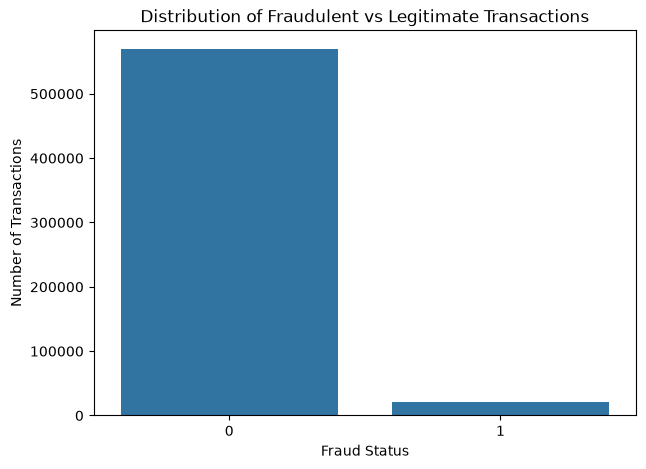

In [8]:
#Distribution of Fraudulent vs Legitimate Transactions
plt.figure(figsize=(7, 5))

sns.countplot(
    data=train_transaction,
    x="isFraud"
)

plt.title("Distribution of Fraudulent vs Legitimate Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

plt.show()

### Initial Observation

The target variable is highly imbalanced, with legitimate transactions substantially outnumbering fraudulent transactions.

This means that a model could achieve high overall accuracy while still performing poorly at identifying fraud.

Therefore, the modeling stage will prioritize metrics such as:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

rather than relying on accuracy alone.

## 5. Missing Value Analysis

The dataset contains a large number of anonymized features, many of which contain missing values.

Missingness is an important consideration in fraud detection because the absence of information may itself contain predictive signals.

For example, certain device, card or identity information may only be available for particular types of transactions.

Instead of automatically removing every column with missing values, we first quantify the extent of missingness and determine how each variable should be handled.

In [9]:
missing = (
    train_transaction.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage = (
    train_transaction.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage
})

missing_summary.head(30)

,Missing Values,Missing Percentage
dist2,552913,93.628374
D7,551623,93.409930
D13,528588,89.509263
D14,528353,89.469469
D12,525823,89.041047
D6,517353,87.606767
D9,515614,87.312290
D8,515614,87.312290
V153,508595,86.123717
V149,508595,86.123717


### Missing Values in Identity Data

The identity dataset contains additional device and digital identity variables.

Because identity information is not available for every transaction, missing values are expected.

These columns will therefore not be removed solely because they contain missing observations.

In [10]:
identity_missing = (
    train_identity.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

identity_missing.head(30)

id_24         96.708798
id_25         96.441868
id_07         96.425922
id_08         96.425922
id_21         96.423149
id_26         96.420375
id_23         96.416215
id_27         96.416215
id_22         96.416215
id_18         68.722137
id_04         54.016071
id_03         54.016071
id_33         49.187079
id_10         48.052110
id_09         48.052110
id_30         46.222432
id_32         46.207872
id_34         46.056034
id_14         44.503685
DeviceInfo    17.726179
id_13         11.726165
id_16         10.325654
id_06          5.108401
id_05          5.108401
id_20          3.447200
id_19          3.407681
id_17          3.372321
id_31          2.739318
DeviceType     2.373243
id_02          2.330257
dtype: float64

## 6. Duplicate Record Check

Duplicate records can introduce bias into analysis and machine learning models.

We check for completely duplicated rows in the transaction and identity datasets.

A duplicate count of zero does not necessarily mean that there are no repeated transactions in the real-world sense; it only means that the complete row is duplicated.

In [11]:
print(
    "Duplicate transaction rows:",
    train_transaction.duplicated().sum()
)

print(
    "Duplicate identity rows:",
    train_identity.duplicated().sum()
)

Duplicate transaction rows: 0
Duplicate identity rows: 0


## 7. Transaction Amount Analysis

`TransactionAmt` represents the monetary value of a transaction.

We inspect its distribution and summary statistics to identify unusual values and understand the scale of transactions in the dataset.

In [12]:
train_transaction["TransactionAmt"].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

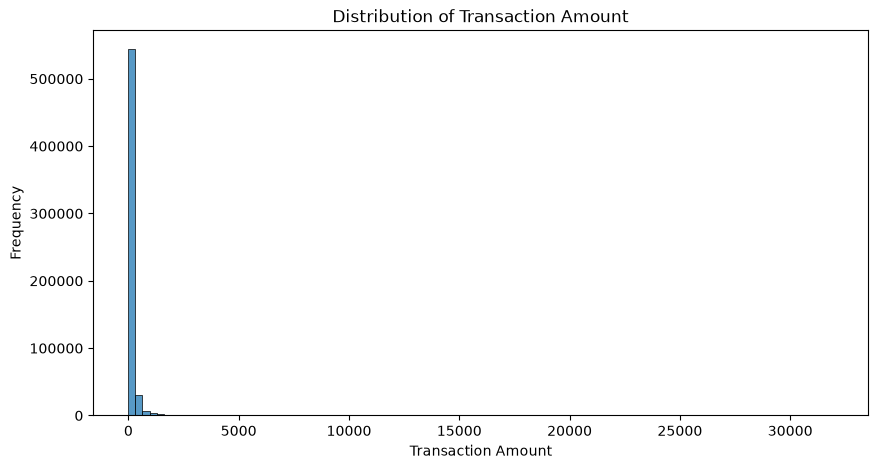

In [13]:
#Distribution of Transaction Amount
plt.figure(figsize=(10, 5))

sns.histplot(
    train_transaction["TransactionAmt"],
    bins=100
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

## 8. Transaction Time Features

The `TransactionDT` variable represents transaction time as an elapsed time value.

Although it is not a conventional timestamp, it can be transformed into meaningful temporal features during feature engineering.

For the preparation stage, we retain the original variable and inspect its range.

In [14]:
train_transaction["TransactionDT"].describe()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

## 9. Merge Transaction and Identity Data

The transaction and identity datasets are linked using the `TransactionID` column.

We perform a left join so that every transaction in the transaction dataset is retained, even when corresponding identity information is unavailable.

This is important because the absence of identity information should not cause a transaction to be discarded.

In [15]:
train = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

test = test_transaction.merge(
    test_identity,
    on="TransactionID",
    how="left"
)

print("Merged train shape:", train.shape)
print("Merged test shape:", test.shape)

Merged train shape: (590540, 434)
Merged test shape: (506691, 433)


## 10. Validate the Merge

After merging the datasets, we verify that the number of transaction records has not unexpectedly decreased.

A left join should preserve the complete transaction dataset.

We also confirm that `TransactionID` remains unique at the transaction level.

In [16]:
print("Original train transaction rows:", len(train_transaction))
print("Merged train rows:", len(train))

print("\nOriginal test transaction rows:", len(test_transaction))
print("Merged test rows:", len(test))

Original train transaction rows: 590540
Merged train rows: 590540

Original test transaction rows: 506691
Merged test rows: 506691


In [17]:
print(
    "Unique TransactionIDs in train:",
    train["TransactionID"].nunique()
)

print(
    "Total train rows:",
    len(train)
)

Unique TransactionIDs in train: 590540
Total train rows: 590540


## 11. High-Missingness Features

Some features contain extremely high proportions of missing values.

However, high missingness does not automatically make a feature useless in fraud detection.

A missing value may itself represent a meaningful behavioral pattern.

Therefore, rather than arbitrarily deleting all high-missingness columns at this stage, we retain the available information and allow feature selection/modeling decisions to be made later based on predictive value and computational constraints.

## 12. Memory Optimization

The merged dataset contains hundreds of columns and hundreds of thousands of observations.

Using default pandas data types can result in unnecessarily high memory consumption.

We therefore optimize numerical data types where possible while preserving the underlying information.

This step is particularly important when working with the IEEE-CIS dataset locally because the full dataset can require several gigabytes of memory.

In [18]:
def reduce_memory_usage(df):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        if pd.api.types.is_numeric_dtype(col_type):

            c_min = df[col].min()
            c_max = df[col].max()

            if pd.api.types.is_integer_dtype(col_type):
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)

            else:
                df[col] = pd.to_numeric(
                    df[col],
                    downcast="float"
                )

    end_mem = df.memory_usage(deep=True).sum() / 1024**2

    print(
        f"Memory usage reduced from {start_mem:.2f} MB "
        f"to {end_mem:.2f} MB"
    )
    print(
        f"Reduction: {(1 - end_mem / start_mem) * 100:.2f}%"
    )

    return df

In [19]:
train = reduce_memory_usage(train)

Memory usage reduced from 1984.20 MB to 1073.53 MB
Reduction: 45.90%


## 13. Final Data Quality Checks

Before saving the prepared dataset, we perform a final validation.

The checks include:

- Dataset dimensions
- Target availability
- Duplicate transactions
- Missing target values
- Data types
- Fraud distribution

These checks ensure that the prepared dataset is suitable for the next stage of the project.

In [20]:
print("Final training dataset shape:", train.shape)

print("\nMissing target values:")
print(train["isFraud"].isnull().sum())

print("\nDuplicate rows:")
print(train.duplicated().sum())

print("\nTarget distribution:")
print(train["isFraud"].value_counts())

print("\nData types:")
print(train.dtypes.value_counts())

Final training dataset shape: (590540, 434)

Missing target values:
0

Duplicate rows:
0

Target distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Data types:
float32    399
str         31
int32        2
int8         1
int16        1
Name: count, dtype: int64


In [21]:
#Final fraud distribution 
final_fraud_distribution = (
    train["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

final_fraud_distribution

isFraud
0    96.5
1     3.5
Name: proportion, dtype: float64

## 14. Save Prepared Dataset

The cleaned and merged training dataset is saved to the processed-data directory.

This file will be used as the starting point for exploratory data analysis and subsequent fraud-risk modeling.

The raw datasets are intentionally preserved separately so that the entire data-preparation process remains reproducible.

In [22]:
OUTPUT_PATH = "../data/processed"

os.makedirs(OUTPUT_PATH, exist_ok=True)

train.to_parquet(
    os.path.join(OUTPUT_PATH, "train_prepared.parquet"),
    index=False
)

print("Prepared training dataset saved successfully.")

Prepared training dataset saved successfully.


# 15. Data Preparation Summary

The raw IEEE-CIS Fraud Detection datasets have now been prepared for downstream analysis.

### Completed Steps

- Loaded transaction and identity datasets
- Inspected dataset dimensions and structure
- Examined the fraud/non-fraud class distribution
- Analyzed missing values
- Checked duplicate records
- Inspected transaction amounts and time information
- Merged transaction and identity data using `TransactionID`
- Validated the merge
- Optimized numerical data types to reduce memory usage
- Performed final data-quality checks
- Saved the prepared training dataset

### Key Considerations

The dataset is highly imbalanced, making fraud detection

In [23]:
import os

processed_file = "../data/processed/train_prepared.parquet"

print("File exists:", os.path.exists(processed_file))

if os.path.exists(processed_file):
    print("File size:", round(os.path.getsize(processed_file) / (1024**2), 2), "MB")

File exists: True
File size: 80.11 MB
